In [2]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline # Using a pipeline for correctness
from imblearn.over_sampling import SMOTE

# Import classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb

In [3]:
df = pd.read_csv('city_day.csv')
df.head()

,NO2,NOx,NH3,CO,SO2,Benzene,Toluene,AQI,AQI_Bucket
0,18.22,17.15,NaN,0.92,27.64,0.00,0.02,NaN,NaN
1,15.69,16.46,NaN,0.97,24.55,3.68,5.50,NaN,NaN
2,19.30,29.70,NaN,17.40,29.07,6.80,16.40,NaN,NaN
3,18.48,17.97,NaN,1.70,18.59,4.43,10.14,NaN,NaN
4,21.42,37.76,NaN,22.10,39.33,7.01,18.89,NaN,NaN


In [4]:
df.shape

(29531, 9)

In [ ]:
df.drop(columns=['Benzene','Toluene'], inplace=True)

In [6]:
df.isnull().sum()

NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
AQI            4681
AQI_Bucket     4681
dtype: int64

In [29]:
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")  

Number of duplicate rows: 2360


In [30]:
df.drop_duplicates(inplace=True)

In [31]:
duplicates = df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")  

Number of duplicate rows: 0


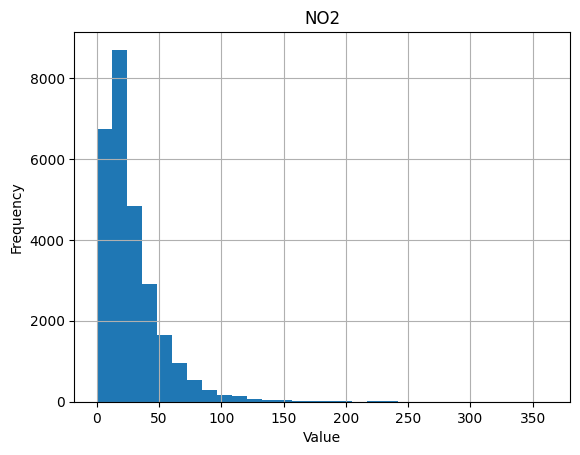

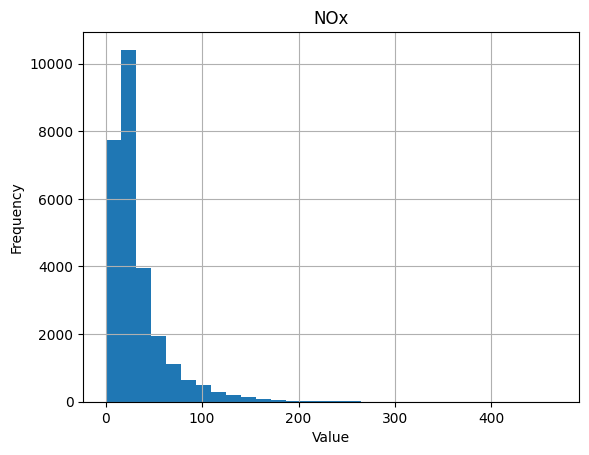

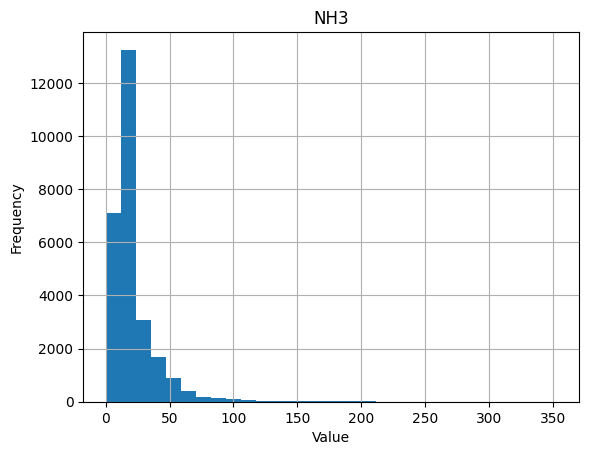

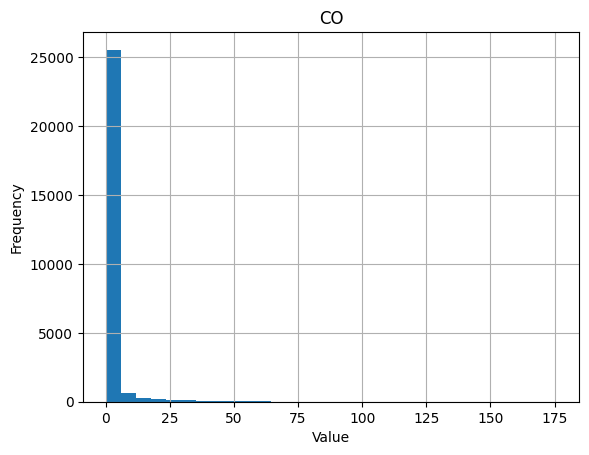

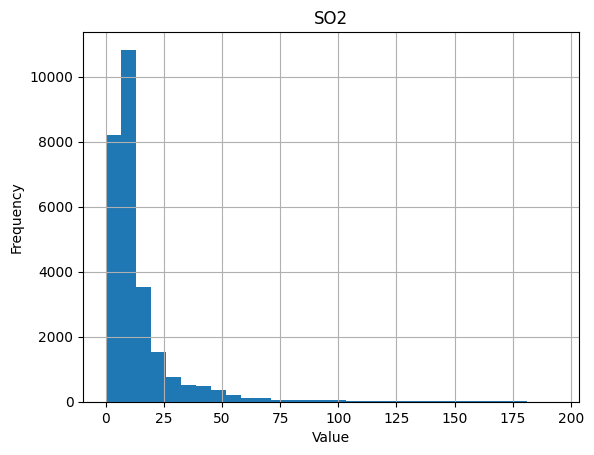

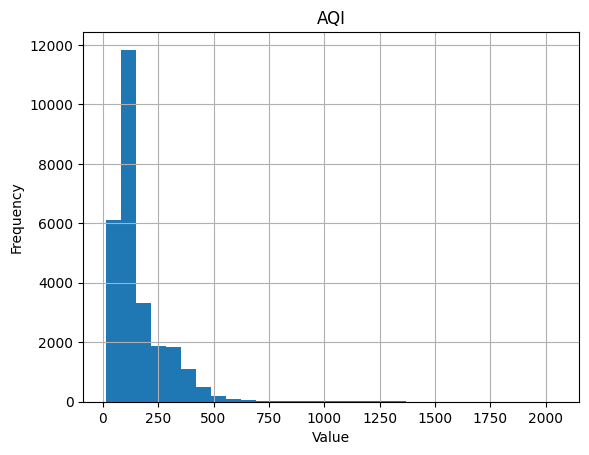

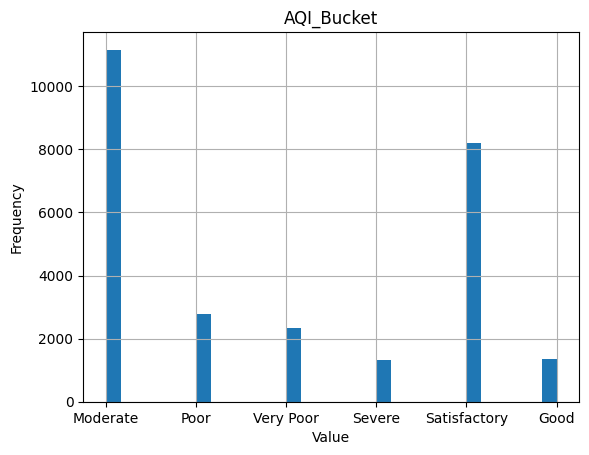

In [32]:
import matplotlib.pyplot as plt
col = ['NO2', 'NOx', 'NH3', 'CO', 'SO2', 'AQI', 'AQI_Bucket']
for c in col:
    hist = df[c].hist(bins=30)
    plt.title(c)
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.show()

In [33]:
df['AQI'].median()

np.float64(118.0)

In [34]:
print((df.loc[df['AQI'] == 118, 'AQI_Bucket']))

0        Moderate
1        Moderate
2        Moderate
3        Moderate
4        Moderate
           ...   
29346    Moderate
29374    Moderate
29400    Moderate
29409    Moderate
29464    Moderate
Name: AQI_Bucket, Length: 2482, dtype: object


In [35]:
df['AQI_Bucket'].mode()

0    Moderate
Name: AQI_Bucket, dtype: object

In [36]:
df['NO2'].fillna(df['NO2'].median(), inplace=True)
df['NOx'].fillna(df['NOx'].median(), inplace=True)  
df['CO'].fillna(df['CO'].median(), inplace=True)
df['NH3'].fillna(df['NH3'].median(), inplace=True)
df['SO2'].fillna(df['SO2'].median(), inplace=True)  
df['AQI'].fillna(df['AQI'].median(), inplace=True)
df['AQI_Bucket'].fillna(df['AQI_Bucket'].mode()[0], inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12384\1642499572.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['NO2'].fillna(df['NO2'].median(), inplace=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12384\1642499572.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27171 entries, 0 to 29530
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NO2              27171 non-null  float64
 1   NOx              27171 non-null  float64
 2   NH3              27171 non-null  float64
 3   CO               27171 non-null  float64
 4   SO2              27171 non-null  float64
 5   AQI              27171 non-null  float64
 6   AQI_Bucket       27171 non-null  object 
 7   AQI_Bucket_Code  27171 non-null  int64  
 8   NO_ratio         27171 non-null  float64
 9   Gas_Total        27171 non-null  float64
 10  Pollutant_Mean   27171 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 2.5+ MB


In [38]:
df['AQI_Bucket'].value_counts()

AQI_Bucket
Moderate        11158
Satisfactory     8216
Poor             2781
Very Poor        2337
Good             1341
Severe           1338
Name: count, dtype: int64

In [ ]:
# import pandas as pd

# # Example data
# aqi_counts = {
#     "Moderate": 11158,
#     "Satisfactory": 8216,
#     "Poor": 2781,
#     "Very Poor": 2337,
#     "Good": 1341,
#     "Severe": 1338
# }

# # Convert to Series
# aqi_series = pd.Series(aqi_counts, name="count")

# # Define mapping
# aqi_mapping = {
#     "Good": 0,
#     "Satisfactory": 1,
#     "Moderate": 2,
#     "Poor": 3,
#     "Very Poor": 4,
#     "Severe": 5
# }

# df["AQI_Bucket_Code"] = df["AQI_Bucket"].map(aqi_mapping)
# df.head()


,NO2,NOx,NH3,CO,SO2,AQI,AQI_Bucket,AQI_Bucket_Code,NO_ratio,Gas_Total,Pollutant_Mean
0,18.22,17.15,15.85,0.92,27.64,118.0,Moderate,2,1.003857,79.78,15.956
1,15.69,16.46,15.85,0.97,24.55,118.0,Moderate,2,0.898625,73.52,14.704
2,19.30,29.70,15.85,17.40,29.07,118.0,Moderate,2,0.628664,111.32,22.264
3,18.48,17.97,15.85,1.70,18.59,118.0,Moderate,2,0.974170,72.59,14.518
4,21.42,37.76,15.85,22.10,39.33,118.0,Moderate,2,0.552632,136.46,27.292


In [40]:
def categorize(val):
    if val <= 150:
        return 0
    elif val <= 300:
        return 1
    else:
        return 2

df['AQI_Bucket_Code'] = df['AQI'].apply(categorize)

In [41]:
df['AQI_Bucket_Code'].value_counts()

AQI_Bucket_Code
0    18098
1     5398
2     3675
Name: count, dtype: int64

In [42]:
df['NO_ratio'] = df['NO2'] / (df['NOx'] + 1)
df['Gas_Total'] = df[['NO2','NOx','NH3','CO','SO2']].sum(axis=1)
df['Pollutant_Mean'] = df[['NO2','NOx','NH3','CO','SO2']].mean(axis=1)


In [43]:
features = [
    'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'NO_ratio', 'Gas_Total', 'Pollutant_Mean'
    ]

target = 'AQI_Bucket_Code'

# --- 3. Prepare Data for Modeling ---
X = df[features]
y = df[target]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"New class distribution:\n{y.value_counts()}")

New class distribution:
AQI_Bucket_Code
0    18098
1     5398
2     3675
Name: count, dtype: int64


In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

In [45]:
df.head()

,NO2,NOx,NH3,CO,SO2,AQI,AQI_Bucket,AQI_Bucket_Code,NO_ratio,Gas_Total,Pollutant_Mean
0,18.22,17.15,15.85,0.92,27.64,118.0,Moderate,0,1.003857,79.78,15.956
1,15.69,16.46,15.85,0.97,24.55,118.0,Moderate,0,0.898625,73.52,14.704
2,19.30,29.70,15.85,17.40,29.07,118.0,Moderate,0,0.628664,111.32,22.264
3,18.48,17.97,15.85,1.70,18.59,118.0,Moderate,0,0.974170,72.59,14.518
4,21.42,37.76,15.85,22.10,39.33,118.0,Moderate,0,0.552632,136.46,27.292


In [ ]:
df.to_csv("environment.csv", index=False)

<Axes: >

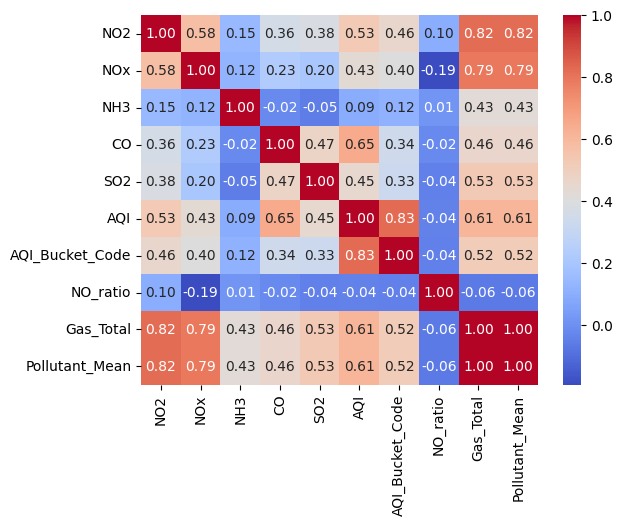

In [47]:
import seaborn as sns
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')   

In [49]:
from distro import name
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline # Using a pipeline for correctness
from imblearn.combine import SMOTETomek
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier
# Import classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
import lightgbm as lgb


# --- 4. Define Regularized Models ---
# We'll test two powerful and well-suited models

# models = {
#     "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42),
#     "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
#     "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
#    # "Support Vector Machine (SVM)": SVC(kernel='rbf', C=1, random_state=42),
#     "XGBoost": xgb.XGBClassifier(objective="multi:softprob", use_label_encoder=False, eval_metric='mlogloss', random_state=42),
#     "LightGBM": lgb.LGBMClassifier(random_state=42)
# }

stacking_model = StackingClassifier(
    estimators=[
        ("Decision Tree", DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)),
        ("K-Nearest Neighbors", KNeighborsClassifier(n_neighbors=5)),
        ("Random Forest", LogisticRegression(max_iter=1000, solver='liblinear', C=0.1)),
        # ("Support Vector Machine (SVM)", SVC(kernel='rbf', C=1, random_state=42)),
        ("XGBoost", xgb.XGBClassifier(objective="multi:softprob", use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
        ("LightGBM", lgb.LGBMClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, solver='liblinear', C=0.1),
    n_jobs=-1
)

# --- 5. Set Up and Run Cross-Validation ---
# Use 5-Fold Stratified Cross-Validation to ensure class distribution is maintained

print(f"\n--- Running Cross-Validation for: {name} ---")

# Create a pipeline that first applies SMOTE to balance the data,
# then trains the classifier. This is the correct way to prevent data leakage.
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTETomek(random_state=42)),
    ('classifier', stacking_model)
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# Perform cross-validation
scores = cross_val_score(pipeline, X_scaled, y_encoded, cv=cv, scoring='accuracy', n_jobs=-1)
# Print the result
print(f"Scores for each fold: {scores}") 
                                                         
print(f"Average Accuracy: {np.mean(scores):.4f}")   

scores = cross_val_score(pipeline, X, y_encoded, cv=cv, scoring='accuracy', n_jobs=-1) # Print the results print(f"Scores for each fold: {scores}") print(f"Average Accuracy: {np.mean(scores):.4f}") print(f"Standard Deviation: {np.std(scores):.4f}")scores = cross_val_score(pipeline, X, y_encoded, cv=cv, scoring='accuracy', n_jobs=-1) # Print the results print(f"Scores for each fold: {scores}") print(f"Average Accuracy: {np.mean(scores):.4f}") print(f"Standard Deviation: {np.std(scores):.4f}")


--- Running Cross-Validation for: <function name at 0x00000217F99BAA20> ---
Scores for each fold: [0.75271389 0.7458594  0.73868237 0.75082812 0.74273095]
Average Accuracy: 0.7462


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# =====================================
# 1. Define Base Models
# =====================================
estimators = [
    ("Decision_Tree", DecisionTreeClassifier(max_depth=10, min_samples_leaf=5, random_state=42)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("Random_Forest", RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1)),
    ("XGBoost", xgb.XGBClassifier(objective="multi:softprob", use_label_encoder=False, eval_metric='mlogloss', random_state=42)),
    ("LightGBM", lgb.LGBMClassifier(random_state=42))
]

# =====================================
# 2. Define Stacking Model
# =====================================
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, solver='liblinear', C=0.1),
    n_jobs=-1
)

# =====================================
# 3. Define Pipeline (Scaling + Balancing + Model)
# =====================================
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTETomek(random_state=42)),
    ('classifier', stacking_model)
])

# =====================================
# 4. Define Parameter Grid for GridSearch
# (Tuning Random Forest inside Stacking)
# =====================================
param_grid = {
    'classifier__Random_Forest__n_estimators': [100, 200, 300],
    'classifier__Random_Forest__max_depth': [10, 20, 30, None],
    'classifier__Random_Forest__min_samples_leaf': [1, 2, 5]
}

# =====================================
# 5. Set Up Cross-Validation
# =====================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =====================================
# 6. Run Grid Search
# =====================================
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit the GridSearchCV
grid_search.fit(X, y_encoded)

# =====================================
# 7. Print Results
# =====================================
print("\n✅ Best Parameters Found:")
print(grid_search.best_params_)
print(f"✅ Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# =====================================
# 8. Evaluate Final Model
# =====================================
best_model = grid_search.best_estimator_

# If you want to see feature importances for Random Forest:
rf_model = best_model.named_steps['classifier'].estimators_[2][1]  # index 2 = Random_Forest
if hasattr(rf_model, 'feature_importances_'):
    print("\nFeature Importances from Random Forest:")
    print(rf_model.feature_importances_)


In [53]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek

# Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# =========================================
# Define models
# =========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "XGBoost": xgb.XGBClassifier(objective="multi:softprob", use_label_encoder=False,
                                 eval_metric='mlogloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(random_state=42)
}

# =========================================
# Define parameter grids (each model separate)
# =========================================
param_grids = {
    "Logistic Regression": {
        'classifier__C': [0.01, 0.1, 1, 10]
    },
    "Decision Tree": {
        'classifier__max_depth': [5, 10, 20, None],
        'classifier__min_samples_leaf': [1, 2, 5]
    },
    "K-Nearest Neighbors": {
        'classifier__n_neighbors': [3, 5, 7, 9]
    },
    "Random Forest": {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [10, 20, 30, None],
        'classifier__min_samples_leaf': [1, 2, 5]
    },
    "XGBoost": {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [3, 6, 10],
        'classifier__learning_rate': [0.05, 0.1, 0.2]
    },
    "LightGBM": {
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [-1, 10, 20],
        'classifier__learning_rate': [0.05, 0.1, 0.2]
    }
}

# =========================================
# Setup cross-validation
# =========================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================================
# Run GridSearchCV and Cross-validation
# =========================================
for name, model in models.items():
    print(f"\n🔹 Running Cross-Validation for: {name} 🔹")

    # Build pipeline (scaling + balancing + model)
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTETomek(random_state=42)),
        ('classifier', model)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(X, y_encoded)

    # Cross-validation with best estimator
    scores = cross_val_score(grid.best_estimator_, X, y_encoded, cv=cv, scoring='accuracy', n_jobs=-1)

    print(f"Best Params: {grid.best_params_}")
    print(f"Best CV Accuracy (GridSearch): {grid.best_score_:.4f}")
    print(f"Cross-val Accuracy (Re-evaluated): {np.mean(scores):.4f} ± {np.std(scores):.4f}")



🔹 Running Cross-Validation for: Logistic Regression 🔹
Best Params: {'classifier__C': 0.1}
Best CV Accuracy (GridSearch): 0.6756
Cross-val Accuracy (Re-evaluated): 0.6756 ± 0.0029

🔹 Running Cross-Validation for: Decision Tree 🔹
Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2}
Best CV Accuracy (GridSearch): 0.7155
Cross-val Accuracy (Re-evaluated): 0.7155 ± 0.0054

🔹 Running Cross-Validation for: K-Nearest Neighbors 🔹
Best Params: {'classifier__n_neighbors': 3}
Best CV Accuracy (GridSearch): 0.7042
Cross-val Accuracy (Re-evaluated): 0.7042 ± 0.0036

🔹 Running Cross-Validation for: Random Forest 🔹
Best Params: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 300}
Best CV Accuracy (GridSearch): 0.7767
Cross-val Accuracy (Re-evaluated): 0.7767 ± 0.0045

🔹 Running Cross-Validation for: XGBoost 🔹


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [00:07:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'classifier__learning_rate': 0.2, 'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best CV Accuracy (GridSearch): 0.7726
Cross-val Accuracy (Re-evaluated): 0.7726 ± 0.0058

🔹 Running Cross-Validation for: LightGBM 🔹
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001206 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 52916, number of used features: 8
[LightGBM] [Info] Start training from score -1.106391
[LightGBM] [Info] Start training from score -1.105020
[LightGBM] [Info] Start training from score -1.084576
Best Params: {'classifier__learning_rate': 0.2, 'classifier__max_depth': -1, 'classifier__n_estimators': 200}
Best CV Accuracy (GridSearch): 0.7625
Cross-val Accuracy (Re-evaluated): 0.7625 ± 0.0043


In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
import joblib

# ================================
# Assuming you already have X and y
# ================================
# Example (only include if you haven’t encoded yet)
# label_encoder = LabelEncoder()
# y_encoded = label_encoder.fit_transform(y)

# ================================
# Define the best Random Forest model
# ================================
rf_best = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# ================================
# Build the pipeline
# ================================
pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('smote', SMOTETomek(random_state=42)),
    ('classifier', rf_best)
])

# ================================
# Cross-validation (5-fold)
# ================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipeline, X_scaled, y_encoded, cv=cv, scoring='accuracy', n_jobs=-1)

print("\n🔹 Random Forest Final Model Evaluation 🔹")
print(f"Cross-validation Scores: {scores}")
print(f"Mean Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

# ================================
# Fit the final model on all data
# ================================
pipeline.fit(X_scaled, y_encoded)

# ================================
# Save the trained model
# ================================
joblib.dump(pipeline, "RandomForest_env_model.h5")
print("\n✅ Model saved as 'RandomForest_env_model.h5'")



🔹 Random Forest Final Model Evaluation 🔹
Cross-validation Scores: [0.78436063 0.77088701 0.77788001 0.77677586 0.77364741]
Mean Accuracy: 0.7767 ± 0.0045

✅ Model saved as 'RandomForest_env_model.h5'
